<p align="center">
  <img src="../../assets/prodinno_logo.png" alt="Prodinno" width="220">
</p>

<h4 align="center">Capstone Project</h4>
<h1 align="center">From Notebook to Production — Diabetes Risk, Explained</h1>
<p align="center"><i>The same Pima Indians Diabetes dataset from the XGBoost session, now trained, served, versioned, retrained, and explained behind a real API and UI.</i></p>

---

## Why this notebook exists

Every session today ended with a trained model sitting inside a notebook. That is where
most ML education stops — and where most real ML work actually *begins*. A model that only
exists as `model.fit(...)` in a cell nobody re-runs is not a product; it is a proof of
concept.

This capstone closes that gap. It walks through the same four questions every team asks
after "the model works":

1. **How do we serve it** so something other than a notebook can ask it for a prediction?
2. **How do we know which version is live**, and can we always get back an older one?
3. **How do we retrain it** when new data arrives, without breaking what's running?
4. **How do we explain a single prediction** to a doctor, a regulator, or a patient who
   will reasonably ask "why did the model say that about *me*"?

The code for all of this lives in `../src/` (`data_processing.py`, `train.py`,
`retrain.py`, `explain.py`), `../api/main.py` (FastAPI), and `../ui/app.py` (Streamlit) —
this notebook imports and exercises that same code directly so you can see it work, then
read the full commented source afterward.

In [1]:
import sys, json
from pathlib import Path

BASE_DIR = Path.cwd().resolve().parent
sys.path.insert(0, str(BASE_DIR / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from data_processing import load_raw, clean, get_feature_target, FEATURE_COLUMNS
from train import train_and_save, MODELS_DIR, REGISTRY_PATH
from explain import shap_explain, lime_explain

pd.set_option("display.max_columns", None)
BASE_DIR

WindowsPath('C:/Users/Asus/Desktop/Git Codes/ML Workshop Prodinno/06_capstone')

## 1. The architecture, in one picture

```
                     ┌─────────────────────────┐
                     │        models/           │
                     │  registry.json           │
                     │  v_20260101_100000/       │◄──────┐
                     │  v_20260101_113000/  ...  │       │ writes new
                     └───────────┬───────────────┘       │ timestamped
                                 │ reads "latest"          │ version
                                 ▼                         │
   ┌──────────┐   HTTP    ┌──────────────┐   POST /retrain │
   │ Streamlit│──────────►│   FastAPI     │─────────────────┘
   │    UI     │◄──────────│  /predict     │
   │           │  JSON     │  /explain     │
   └──────────┘           │  /versions    │
                            └──────────────┘
```

Two Docker containers (`api`, `ui`) share one `models/` volume. The UI never touches the
model or the data directly — exactly like a real deployment, it only ever talks to the API
over HTTP. That separation is what lets you scale, redeploy, or even rewrite the UI in a
different language without touching the model-serving code at all.

## 2. Training and the versioning story

`train.py` doesn't overwrite a model file — it creates a brand-new folder named after the
exact moment it ran, `v_<YYYYMMDD_HHMMSS>/`, and appends an entry to `models/registry.json`
with that version's metrics and a `"latest"` pointer. Nothing already on disk is ever
deleted or modified.

This matters for three very ordinary reasons any team runs into:

- **Rollback.** If a retrain quietly makes things worse (data drift, a bad batch, a bug),
  you point `"latest"` back at the previous timestamp instead of debugging under pressure.
- **Audit.** "Which model produced this prediction on March 3rd?" has an exact, timestamped
  answer instead of a shrug.
- **Comparison.** Every version's `metrics.json` is sitting right there, so "did the retrain
  actually help?" is a file read, not an investigation.

Let's train a version right now and look at what gets written to disk.

In [2]:
from datetime import datetime

now = datetime.now().strftime("%Y%m%d_%H%M%S")
result = train_and_save(now=now, note="capstone walkthrough notebook")
print(json.dumps(result, indent=2))

{
  "version": "v_20260820_214555",
  "metrics": {
    "accuracy": 0.8701,
    "precision": 0.8148,
    "recall": 0.8148,
    "f1": 0.8148,
    "roc_auc": 0.9524,
    "n_train_rows": 614,
    "n_test_rows": 154,
    "n_total_rows": 768
  }
}


In [3]:
registry = json.loads(REGISTRY_PATH.read_text())
history = pd.DataFrame([
    {"version": v["version"], "timestamp": v["timestamp"], "note": v.get("note", ""), **v["metrics"]}
    for v in registry["versions"]
])
history.sort_values("timestamp", ascending=False)

,version,timestamp,note,accuracy,precision,recall,f1,roc_auc,n_train_rows,n_test_rows,n_total_rows
1,v_20260820_214555,20260820_214555,capstone walkthrough notebook,0.8701,0.8148,0.8148,0.8148,0.9524,614,154,768
0,v_20260820_213651,20260820_213651,initial bootstrap model,0.8701,0.8148,0.8148,0.8148,0.9524,614,154,768


> **How to read this table:** every row is a real, independently trained model — not a
> hyperparameter tweak on paper. If two versions show meaningfully different `roc_auc`, that
> is a genuine signal something changed (new data, a code change in `train.py`, a different
> random seed) and is worth investigating before promoting a new "latest".

## 3. Explainability — two different answers to "why?"

A patient-risk model that can't explain itself is very hard to trust in a clinical setting.
Two popular tools answer "why did the model predict this for *this one patient*" in
genuinely different ways.

### 3.1 SHAP — exact, game-theoretic attribution

SHAP is built on **Shapley values**, a concept from cooperative game theory: if $F$ is the
full set of features, the contribution of feature $i$ to a particular prediction is its
*average marginal contribution* across every possible order features could be "added" to
the prediction:

$$
\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\Big[f(S \cup \{i\}) - f(S)\Big]
$$

That sum over every subset $S$ is exponential in the number of features — computing it
exactly would be far too slow in general. `shap.TreeExplainer` gets around this specifically
for tree ensembles (like our XGBoost model) by exploiting the tree structure to compute the
*exact* Shapley values in low-order polynomial time — no approximation needed. The payoff of
that exactness is a property called **local accuracy**: the contributions always sum exactly
to (prediction − base value), so nothing is left unexplained.

### 3.2 LIME — a local, model-agnostic surrogate

LIME ("Local Interpretable Model-agnostic Explanations") doesn't look inside the model at
all. Instead, for one specific input $x$, it:

1. generates many perturbed samples around $x$,
2. asks the real model $f$ for a prediction on each one,
3. fits a small interpretable model $g$ (a sparse linear model, here) to those (perturbation,
   prediction) pairs, weighted by how close each perturbation is to $x$.

Formally, the explanation is:

$$
\xi(x) = \arg\min_{g \in G} \; \mathcal{L}(f, g, \pi_x) + \Omega(g)
$$

where $\mathcal{L}$ is the locality-weighted squared error between $f$'s and $g$'s
predictions near $x$ (closer perturbations, via the proximity kernel $\pi_x$, count more),
and $\Omega(g)$ penalizes complexity (keeping $g$ to a handful of features). Because LIME
never opens the model, it works on *any* black box — the price is that it's an
approximation that can vary slightly between runs and is only trustworthy in the
immediate neighborhood of $x$, not globally.

### 3.3 The practical difference

| | SHAP (TreeExplainer) | LIME |
|---|---|---|
| Scope | Exact, for tree models | Approximate, for any model |
| Guarantee | Contributions sum exactly to the prediction | No such guarantee |
| Speed | Fast (polynomial, tree-structure-aware) | Slower (many re-predictions per explanation) |
| Output | One signed value per feature | A handful of human-readable rules with weights |

Seeing both agree on the big drivers for the same patient is a good trust signal; seeing
them disagree is worth a closer look, not a coin-flip.

In [4]:
df = load_raw(BASE_DIR / "data" / "diabetes.csv")
df_clean, impute_stats = clean(df)
X, y = get_feature_target(df_clean)

version_dir = MODELS_DIR / result["version"]
import joblib
model = joblib.load(version_dir / "model.joblib")
background = pd.read_csv(version_dir / "background_sample.csv")

sample_row = X.iloc[[7]]
sample_row

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
7,10.0,115.0,70.0,27.0,102.5,35.3,0.134,29.0


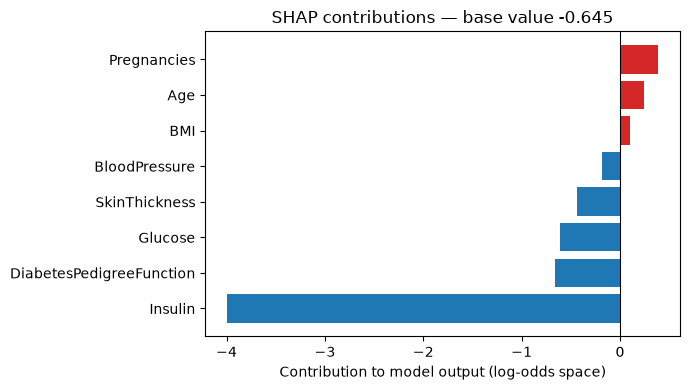

In [5]:
shap_result = shap_explain(model, background, sample_row)
shap_series = pd.Series(shap_result["contributions"]).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in shap_series.values]
ax.barh(shap_series.index, shap_series.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"SHAP contributions — base value {shap_result['base_value']:.3f}")
ax.set_xlabel("Contribution to model output (log-odds space)")
plt.tight_layout()
plt.show()

> **How to read this:** red bars push the prediction toward "diabetes", blue bars pull it
> away. Their sum, plus the base value, reconstructs the model's raw output exactly — that
> exactness is the guarantee SHAP gives you that LIME cannot.

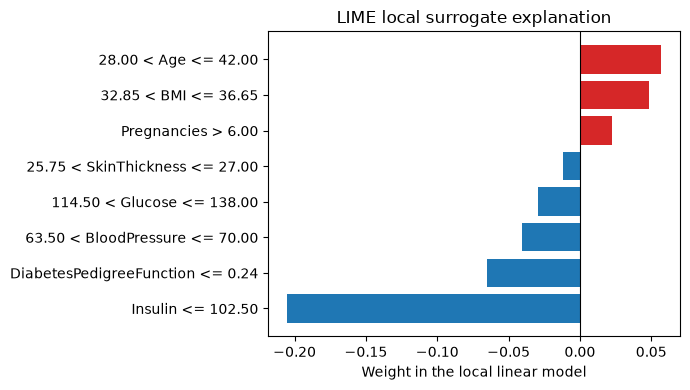

In [6]:
lime_result = lime_explain(model, background, sample_row)
lime_df = pd.DataFrame(lime_result["contributions"]).set_index("rule").sort_values("weight")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in lime_df["weight"]]
ax.barh(lime_df.index, lime_df["weight"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("LIME local surrogate explanation")
ax.set_xlabel("Weight in the local linear model")
plt.tight_layout()
plt.show()

> **How to read this:** each bar is a *rule* (a condition on one feature) that held for
> this patient, and its weight in LIME's small local linear model. Compare the top 2-3 rules
> here against the top 2-3 SHAP bars above — for a well-behaved model on a clear-cut case,
> they usually point at the same features, even though the two methods compute this in
> completely different ways.

## 4. Retraining, live

Calling `/retrain` on the API (or running `retrain.py` directly) re-runs this exact training
routine and registers another new version — this is the same function we called above,
just wrapped behind an HTTP endpoint so the UI's "Retrain model" button can trigger it
without anyone touching a terminal. Nothing from the previous version is deleted; the
registry now simply has one more entry, and `"latest"` moves forward.

In a real system, `retrain.py`'s `extra_rows_path` argument is where newly-collected patient
records would be appended before refitting — the versioning story doesn't change at all,
whether the retrain used the exact same data or genuinely new rows.

In [7]:
registry = json.loads(REGISTRY_PATH.read_text())
print(f"Total versions on disk: {len(registry['versions'])}")
print(f"Latest: {registry['latest']}")

Total versions on disk: 2
Latest: v_20260820_214555


## 5. Try it live

With the API and UI running (`docker compose up --build` from `06_capstone/`, or the two
`uvicorn`/`streamlit` commands from the capstone README), open **http://localhost:8501** and:

1. Enter a few patient values (leave one at the biologically-impossible `0` — the API
   imputes it exactly like the XGBoost notebook's data-impurity lesson).
2. Click **Predict**, then **Explain this prediction** to see the same SHAP/LIME comparison
   you just built here, generated live from the running API.
3. Click **Retrain model** and watch a new row appear in the version history table.

That's the whole loop: notebook → shared cleaning logic → versioned model → API → UI →
explanation — all traceable back to the exact same `data_processing.py` rules this notebook
just used.